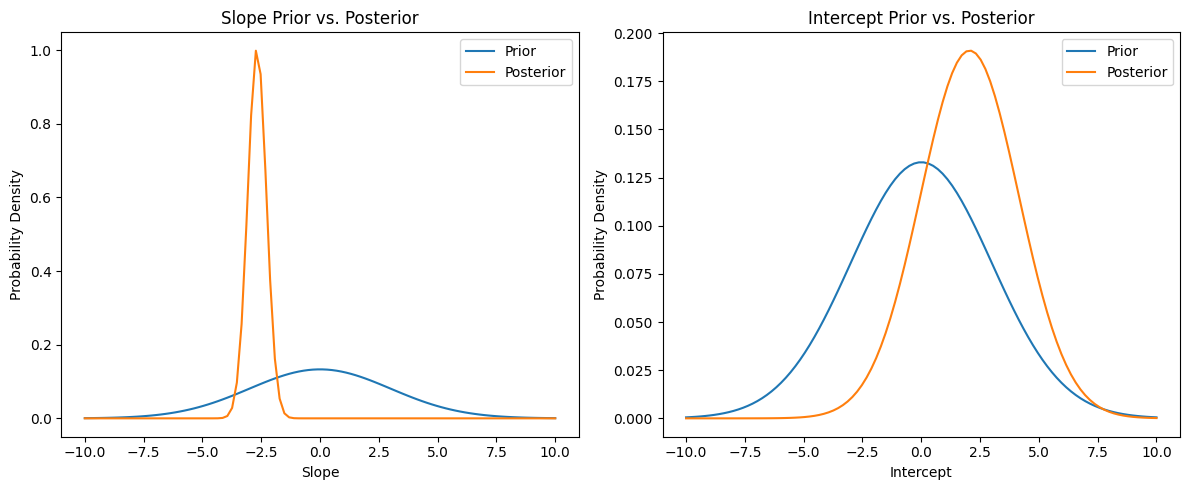

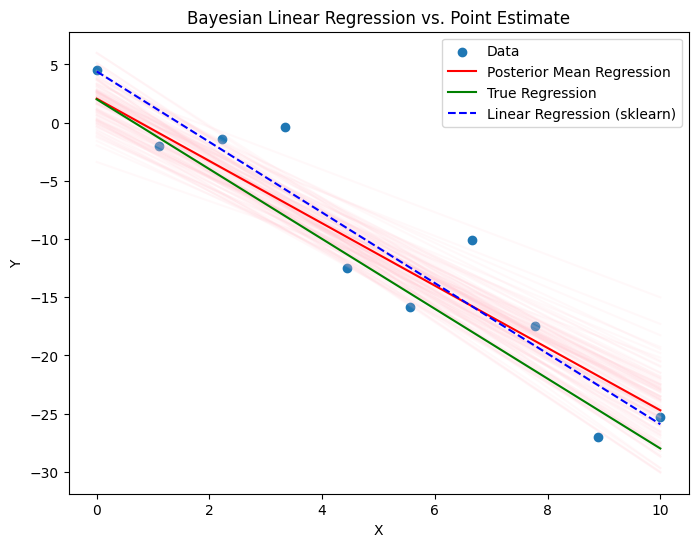

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

# Generate synthetic data
np.random.seed(42)
n_samples = 10
x = np.linspace(0, 10, n_samples)
true_slope = -3
true_intercept = 2
y = true_slope * x + true_intercept + np.random.normal(0, 5, n_samples)

prior_mean = np.array([0, 0])  # Prior mean for slope and intercept
prior_std = np.array([3, 3])  # Prior std for slope and intercept

# Define likelihood (assuming Gaussian noise)
likelihood_std = 5

def calculate_posterior(x, y, prior_mean, prior_std, likelihood_std):
    x_matrix = np.vstack([x, np.ones(len(x))]).T
    covariance_prior = np.diag(prior_std**2)
    covariance_likelihood = likelihood_std**2 * np.identity(len(x))
    covariance_posterior = np.linalg.inv(np.linalg.inv(covariance_prior) + x_matrix.T @ np.linalg.inv(covariance_likelihood) @ x_matrix)
    mean_posterior = covariance_posterior @ (np.linalg.inv(covariance_prior) @ prior_mean + x_matrix.T @ np.linalg.inv(covariance_likelihood) @ y)
    return mean_posterior, covariance_posterior

posterior_mean, posterior_covariance = calculate_posterior(x, y, prior_mean, prior_std, likelihood_std)
posterior_slope_mean, posterior_intercept_mean = posterior_mean
posterior_slope_std, posterior_intercept_std = np.sqrt(np.diag(posterior_covariance))


def bayesian_predictive_distribution(x_new, x_data, y_data, prior_mean, prior_std, likelihood_std, num_samples=1000):
    """
    Calculates the Bayesian predictive distribution for a new data point x_new.

    Args:
        x_new (float): The new x value for which to calculate the predictive distribution.
        x_data (np.array): The observed x data.
        y_data (np.array): The observed y data.
        prior_mean (np.array): The mean of the prior distribution for slope and intercept.
        prior_std (np.array): The standard deviation of the prior distribution for slope and intercept.
        likelihood_std (float): The standard deviation of the likelihood (noise).
        num_samples (int): Number of samples from the posterior.

    Returns:
        np.array: Samples from the predictive distribution for y_new.
    """


    posterior_mean, posterior_covariance = calculate_posterior(x_data, y_data, prior_mean, prior_std, likelihood_std)
    posterior_samples = np.random.multivariate_normal(posterior_mean, posterior_covariance, num_samples)

    predictive_samples = []  # Initialize as an empty list
    for slope, intercept in posterior_samples:
        y_new_mean = slope * x_new + intercept
        y_new_sample = np.random.normal(y_new_mean, likelihood_std)
        predictive_samples.append(y_new_sample)

    return np.array(predictive_samples)


# Plot prior and posterior distributions for slope
slope_range = np.linspace(-10, 10, 100)
prior_slope_pdf = stats.norm.pdf(slope_range, prior_mean[0], prior_std[0])
posterior_slope_pdf = stats.norm.pdf(slope_range, posterior_slope_mean, posterior_slope_std)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(slope_range, prior_slope_pdf, label='Prior')
plt.plot(slope_range, posterior_slope_pdf, label='Posterior')
plt.title('Slope Prior vs. Posterior')
plt.xlabel('Slope')
plt.ylabel('Probability Density')
plt.legend()

# Plot prior and posterior distributions for intercept
intercept_range = np.linspace(-10, 10, 100)
prior_intercept_pdf = stats.norm.pdf(intercept_range, prior_mean[1], prior_std[1])
posterior_intercept_pdf = stats.norm.pdf(intercept_range, posterior_intercept_mean, posterior_intercept_std)

plt.subplot(1, 2, 2)
plt.plot(intercept_range, prior_intercept_pdf, label='Prior')
plt.plot(intercept_range, posterior_intercept_pdf, label='Posterior')
plt.title('Intercept Prior vs. Posterior')
plt.xlabel('Intercept')
plt.ylabel('Probability Density')
plt.legend()

plt.tight_layout()
plt.show()

# Plot the regression line with uncertainty
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label='Data')

# Sample from posterior for uncertainty
num_samples_posterior = 100
posterior_samples = np.random.multivariate_normal(posterior_mean, posterior_covariance, num_samples_posterior)

for slope, intercept in posterior_samples:
    plt.plot(x, slope * x + intercept, color='pink', alpha=0.1)

plt.plot(x, posterior_slope_mean * x + posterior_intercept_mean, color='red', label='Posterior Mean Regression')
plt.plot(x, true_slope * x + true_intercept, color='green', label='True Regression')

# Point estimate using Linear Regression (sklearn)
lr = LinearRegression()
lr.fit(x.reshape(-1, 1), y)
lr_slope = lr.coef_[0]
lr_intercept = lr.intercept_
plt.plot(x, lr_slope * x + lr_intercept, color='blue', linestyle='--', label='Linear Regression (sklearn)')

plt.title('Bayesian Linear Regression vs. Point Estimate')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

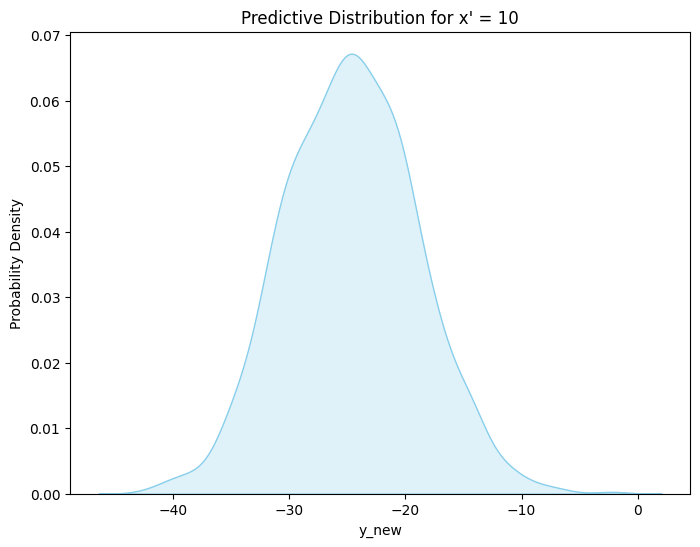

In [ ]:
x_new = 10  # New x value for prediction

predictive_samples = bayesian_predictive_distribution(x_new, x, y, prior_mean, prior_std, likelihood_std)

# Plot the predictive distribution
plt.figure(figsize=(8, 6))
sns.kdeplot(predictive_samples, fill=True, color='skyblue')  # Using KDE plot
plt.title(f'Predictive Distribution for x\' = {x_new}')
plt.xlabel('y_new')
plt.ylabel('Probability Density')
plt.show()